In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt

In [19]:
df_tfidf = pd.read_csv("Data/features_tfidf_clustering.csv")   # uid + svd_0..svd_49
df_text  = pd.read_csv("Data/dataset_main.csv")                     # split, label, attack_type, source, text

df = df_tfidf.merge(df_text[['uid', 'split', 'label', 'attack_type', 'source']], on='uid', how='left')

print(df.shape)
print(df.dtypes)
print(df['split'].value_counts())
print(df['label'].value_counts())
print(df.isna().sum()[df.isna().sum() > 0])   # flag any missing values — NaNs here mean the merge didn't match on uid
df.head()

(3582, 15)
uid                str
svd_0          float64
svd_1          float64
svd_2          float64
svd_3          float64
svd_4          float64
svd_5          float64
svd_6          float64
svd_7          float64
svd_8          float64
svd_9          float64
split              str
label            int64
attack_type        str
source             str
dtype: object
split
train    3582
Name: count, dtype: int64
label
1    3582
Name: count, dtype: int64
Series([], dtype: int64)


,uid,svd_0,svd_1,svd_2,svd_3,svd_4,svd_5,svd_6,svd_7,svd_8,svd_9,split,label,attack_type,source
0,safeguard:test:10,0.139052,0.143208,0.019439,0.004847,-0.016136,-0.101133,0.169273,-0.188789,0.056721,-0.058732,train,1,instruction_override,safeguard
1,safeguard:test:1006,0.155829,0.130020,-0.153673,0.034344,-0.012210,0.090094,0.163268,-0.081320,0.032374,0.097912,train,1,prompt_leak_exfiltration,safeguard
2,safeguard:test:1012,0.134426,0.139064,-0.154929,-0.041744,-0.004253,-0.035217,-0.144333,-0.040033,-0.000452,0.139818,train,1,prompt_leak_exfiltration,safeguard
3,safeguard:test:1019,0.098067,-0.011824,0.005060,-0.092101,0.133428,-0.019575,0.074380,-0.026829,0.012352,0.010699,train,1,prefix_refusal_suppression,safeguard
4,safeguard:test:1020,0.155365,0.115442,-0.095481,-0.039530,-0.017563,-0.077853,-0.091372,-0.026394,0.019898,-0.020547,train,1,prompt_leak_exfiltration,safeguard


In [20]:
df_cluster = df[(df['split'] == 'train') & (df['label'] == 1)].copy()
meta_cols = ['uid', 'split', 'source', 'attack_type', 'label']
feature_cols = [c for c in df.columns if c not in meta_cols]   # resolves to svd_0..svd_49

X = df_cluster[feature_cols]        # this is what DBSCAN sees
meta = df_cluster[meta_cols]        # kept alongside, same row order, same index

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

(3582, 10)


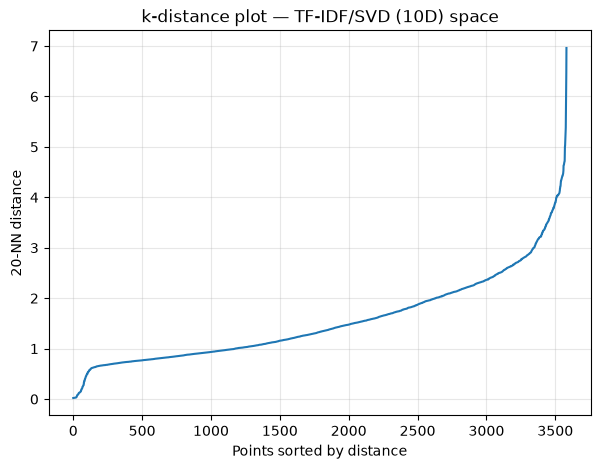

50th percentile: 1.333
75th percentile: 2.048
90th percentile: 2.711
95th percentile: 3.276
97th percentile: 3.700
98th percentile: 4.003
99th percentile: 4.366
99.5th percentile: 4.653
100th percentile: 6.961


In [21]:
X_reduced = X_scaled
n_components = X_reduced.shape[1]   # = 50
print(X_reduced.shape)

min_samples = 2 * n_components   # = 100
k = min_samples

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_reduced)
distances, indices = neighbors_fit.kneighbors(X_reduced)

k_dist = np.sort(distances[:, k-1])

plt.figure(figsize=(7, 5))
plt.plot(k_dist)
plt.ylabel(f"{k}-NN distance")
plt.xlabel("Points sorted by distance")
plt.title(f"k-distance plot — TF-IDF/SVD ({n_components}D) space")
plt.grid(alpha=0.3)
plt.show()

for p in [50, 75, 90, 95, 97, 98, 99, 99.5, 100]:
    print(f"{p}th percentile: {np.percentile(k_dist, p):.3f}")

In [22]:
eps_candidates = [3.0, 4.0, 5.0]   # placeholder — replace based on k-distance plot/percentiles

for eps_test in eps_candidates:
    db_test = DBSCAN(eps=eps_test, min_samples=min_samples)
    labels_test = db_test.fit_predict(X_reduced)
    mask_test = labels_test != -1
    if mask_test.sum() == 0 or len(set(labels_test[mask_test])) < 2:
        print(f"eps={eps_test}: not enough non-noise clusters to score")
        continue
    sil = silhouette_score(X_reduced[mask_test], labels_test[mask_test])
    dbi = davies_bouldin_score(X_reduced[mask_test], labels_test[mask_test])
    n_clust = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    print(f"eps={eps_test}: clusters={n_clust}, silhouette={sil:.3f}, davies-bouldin={dbi:.3f}")


eps=3.0: not enough non-noise clusters to score
eps=4.0: clusters=2, silhouette=0.726, davies-bouldin=0.269
eps=5.0: not enough non-noise clusters to score


In [23]:
eps = 4.0   # placeholder — set from eps_candidates results

db = DBSCAN(eps=eps, min_samples=min_samples)
cluster_labels = db.fit_predict(X_reduced)

meta = meta.copy()
meta['cluster_id'] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(cluster_labels):.1%})")
print(pd.Series(cluster_labels).value_counts().sort_index())

plt.figure(figsize=(8, 6))

noise_mask = cluster_labels == -1

Clusters found: 2
Noise points: 13 (0.4%)
-1      13
 0    3546
 1      23
Name: count, dtype: int64


<Figure size 800x600 with 0 Axes>

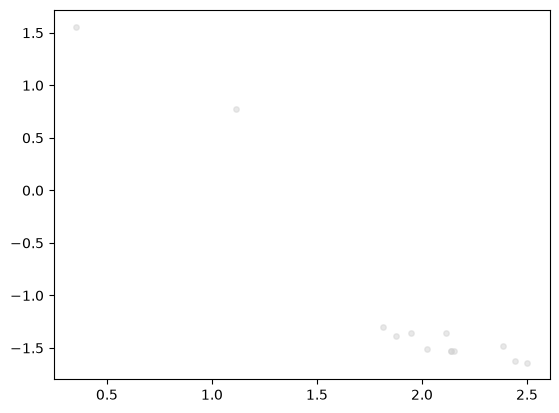

In [24]:
plt.scatter(X_reduced[noise_mask, 0], X_reduced[noise_mask, 1],
            c='lightgray', s=15, label='noise', alpha=0.5)

C:\Users\seusa\AppData\Local\Temp\ipykernel_39404\2269928789.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


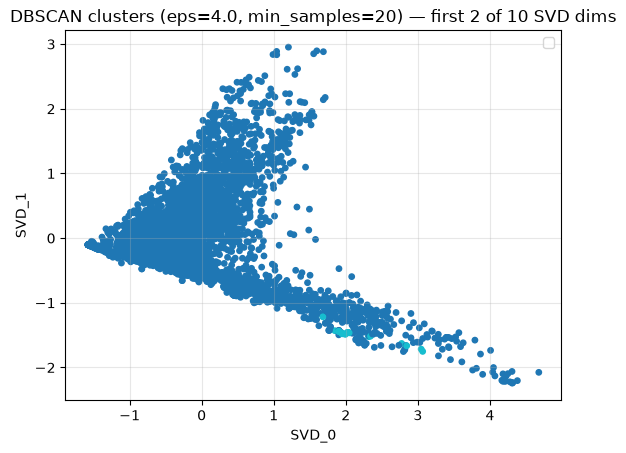

In [25]:
plt.scatter(X_reduced[~noise_mask, 0], X_reduced[~noise_mask, 1],
            c=cluster_labels[~noise_mask], cmap='tab10', s=15)

plt.xlabel("SVD_0")
plt.ylabel("SVD_1")
plt.title(f"DBSCAN clusters (eps={eps}, min_samples={min_samples}) — first 2 of {n_components} SVD dims")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [26]:
df_desc = df_cluster[feature_cols].copy()
df_desc['cluster_id'] = meta['cluster_id'].values
df_desc['uid'] = meta['uid'].values
df_desc['attack_type'] = meta['attack_type'].values

overall_mean = df_cluster[feature_cols].mean()
cluster_means = df_desc.groupby('cluster_id')[feature_cols].mean()
diff_from_overall = cluster_means.subtract(overall_mean, axis=1)

print(diff_from_overall.T)

ari = adjusted_rand_score(df_desc['attack_type'], df_desc['cluster_id'])
nmi = normalized_mutual_info_score(df_desc['attack_type'], df_desc['cluster_id'])
print(f"ARI: {ari:.3f}")
print(f"NMI: {nmi:.3f}")

mask = df_desc['cluster_id'] != -1
ari_clean = adjusted_rand_score(df_desc['attack_type'][mask], df_desc['cluster_id'][mask])
nmi_clean = normalized_mutual_info_score(df_desc['attack_type'][mask], df_desc['cluster_id'][mask])
print(f"ARI (excl. noise): {ari_clean:.3f}")
print(f"NMI (excl. noise): {nmi_clean:.3f}")

cluster_id        -1         0         1
svd_0       0.176430 -0.001958  0.202083
svd_1      -0.195998  0.002474 -0.270670
svd_2      -0.042806  0.000165 -0.001235
svd_3       0.004952 -0.000032  0.002102
svd_4      -0.090552  0.000994 -0.102032
svd_5      -0.096849  0.001346 -0.152837
svd_6       0.055647 -0.000531  0.050361
svd_7       0.218294 -0.003170  0.365377
svd_8       0.347193 -0.005812  0.699743
svd_9       0.074952 -0.000891  0.095003
ARI: 0.001
NMI: 0.017
ARI (excl. noise): 0.001
NMI (excl. noise): 0.012


In [27]:
print(df_desc[df_desc['cluster_id'] == -1]['attack_type'].value_counts())

attack_type
roleplay_jailbreak          11
prompt_leak_exfiltration     2
Name: count, dtype: int64


In [28]:
composition = pd.crosstab(df_desc['cluster_id'], df_desc['attack_type'], normalize='index') * 100
sizes = df_desc['cluster_id'].value_counts().sort_index()
print(composition.round(1))
print(sizes)


attack_type  fake_completion_delimiter  harmful_content_request  \
cluster_id                                                        
-1                                 0.0                      0.0   
 0                                 1.3                      2.6   
 1                                 0.0                      0.0   

attack_type  instruction_override  other_injection  \
cluster_id                                           
-1                            0.0              0.0   
 0                           23.1             17.4   
 1                            0.0              0.0   

attack_type  prefix_refusal_suppression  prompt_leak_exfiltration  \
cluster_id                                                          
-1                                  0.0                      15.4   
 0                                  7.6                      27.3   
 1                                  0.0                       0.0   

attack_type  roleplay_jailbreak  social_enginee

In [29]:
for cid in diff_from_overall.index:
    top = diff_from_overall.loc[cid].abs().sort_values(ascending=False).head(3)
    print(f"\nCluster {cid} top differentiators:")
    print(diff_from_overall.loc[cid][top.index])


Cluster -1 top differentiators:
svd_8    0.347193
svd_7    0.218294
svd_1   -0.195998
Name: -1, dtype: float64

Cluster 0 top differentiators:
svd_8   -0.005812
svd_7   -0.003170
svd_1    0.002474
Name: 0, dtype: float64

Cluster 1 top differentiators:
svd_8    0.699743
svd_7    0.365377
svd_1   -0.270670
Name: 1, dtype: float64


In [30]:
for cid in sorted(df_desc['cluster_id'].unique()):
    sample_uids = df_desc[df_desc['cluster_id'] == cid]['uid'].sample(
        min(3, (df_desc['cluster_id'] == cid).sum()), random_state=42
    )
    examples = df_text[df_text['uid'].isin(sample_uids)][['uid', 'text']]
    print(f"\n=== Cluster {cid} examples ===")
    print(examples.to_string(index=False))


=== Cluster -1 examples ===
                     uid                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [33]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

n_attack_types = df_cluster['attack_type'].nunique()

km = KMeans(n_clusters=n_attack_types, random_state=42, n_init=10)
km_labels = km.fit_predict(X_reduced)
print("TF-IDF KMeans — ARI:", adjusted_rand_score(df_cluster['attack_type'], km_labels),
      "NMI:", normalized_mutual_info_score(df_cluster['attack_type'], km_labels))

gmm = GaussianMixture(n_components=n_attack_types, random_state=42)
gmm_labels = gmm.fit_predict(X_reduced)
print("TF-IDF GMM — ARI:", adjusted_rand_score(df_cluster['attack_type'], gmm_labels),
      "NMI:", normalized_mutual_info_score(df_cluster['attack_type'], gmm_labels))

TF-IDF KMeans — ARI: 0.11080949622810135 NMI: 0.2889049348642024
TF-IDF GMM — ARI: 0.2976216992081621 NMI: 0.4177493881725596
